In [1]:
# import necessary libraries
import  pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:
# Read csv file
df=pd.read_csv('Bengaluru_House_Data.csv')
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 1.6 MB


In [4]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [5]:
df=df.drop(["area_type","availability","society","balcony"],axis=1)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13319 non-null  str    
 1   size        13304 non-null  str    
 2   total_sqft  13320 non-null  str    
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), str(3)
memory usage: 817.4 KB


In [6]:
df['location'].value_counts()
df['location']=df['location'].fillna('Sarjapur Road')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13320 non-null  str    
 1   size        13304 non-null  str    
 2   total_sqft  13320 non-null  str    
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), str(3)
memory usage: 815.8 KB


In [7]:
df['size'].value_counts()
df['size']=df['size'].fillna('2 BHK')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13320 non-null  str    
 1   size        13320 non-null  str    
 2   total_sqft  13320 non-null  str    
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), str(3)
memory usage: 814.2 KB


In [8]:
df['bath']=df['bath'].fillna(df['bath'].median())
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13320 non-null  str    
 1   size        13320 non-null  str    
 2   total_sqft  13320 non-null  str    
 3   bath        13320 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), str(3)
memory usage: 814.2 KB


In [9]:
df['size'].unique()
out=[int (i.split()[0]) for i in df['size']]    
df['bhk']=out
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13320 non-null  str    
 1   size        13320 non-null  str    
 2   total_sqft  13320 non-null  str    
 3   bath        13320 non-null  float64
 4   price       13320 non-null  float64
 5   bhk         13320 non-null  int64  
dtypes: float64(2), int64(1), str(3)
memory usage: 918.3 KB


In [10]:
df[df['bhk']>20]

,location,size,total_sqft,bath,price,bhk
1718,2Electronic City Phase II,27 BHK,8000,27.0,230.0,27
4684,Munnekollal,43 Bedroom,2400,40.0,660.0,43


In [11]:
# clean total_sqft column
df['total_sqft'].unique()
def convert(a):
    l=a.split('-')
    if len(l)==2:
        return (float(l[0])+float(l[1]))/2
    try:
        return float(a)
    except:
        return None
df['total_sqft']=df['total_sqft'].apply(convert)

In [12]:
df['price_per_sqft']=df['price']*100000/df['total_sqft']
df['price_per_sqft']

0         3699.810606
1         4615.384615
2         4305.555556
3         6245.890861
4         4250.000000
             ...     
13315     6689.834926
13316    11111.111111
13317     5258.545136
13318    10407.336319
13319     3090.909091
Name: price_per_sqft, Length: 13320, dtype: float64

In [13]:
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,13274.000000,13320.000000,13320.000000,13320.000000,1.327400e+04
mean,1559.626694,2.688814,112.565627,2.802778,7.907501e+03
std,1238.405258,1.338754,148.971674,1.294496,1.064296e+05
min,1.000000,1.000000,8.000000,1.000000,2.678298e+02
25%,1100.000000,2.000000,50.000000,2.000000,4.266865e+03
50%,1276.000000,2.000000,72.000000,3.000000,5.434306e+03
75%,1680.000000,3.000000,120.000000,3.000000,7.311746e+03
max,52272.000000,40.000000,3600.000000,43.000000,1.200000e+07


In [14]:
df['location']=df['location'].apply(lambda x: x.strip())
df['location'].value_counts()

loc_lessthan_10=df['location'].value_counts()
loc_lessthan_10=loc_lessthan_10[loc_lessthan_10<=10]
loc_lessthan_10

location
Ganga Nagar                                        10
Dairy Circle                                       10
Sadashiva Nagar                                    10
Naganathapura                                      10
Nagappa Reddy Layout                               10
                                                   ..
Pattegarhpalya                                      1
Tilak Nagar                                         1
12th cross srinivas nagar banshankari 3rd stage     1
Havanur extension                                   1
Abshot Layout                                       1
Name: count, Length: 1054, dtype: int64

In [15]:
df['location']=df['location'].apply(lambda x: 'other' if x in loc_lessthan_10 else x)

In [16]:
df['location'].value_counts()

location
other                        2886
Whitefield                    541
Sarjapur  Road                399
Electronic City               304
Kanakpura Road                273
                             ... 
Tindlu                         11
2nd Phase Judicial Layout      11
Marsur                         11
Thyagaraja Nagar               11
HAL 2nd Stage                  11
Name: count, Length: 242, dtype: int64

In [17]:
# Total sqft per bhk 
(df['total_sqft']/df['bhk']).describe()

count    13274.000000
mean       575.074878
std        388.205175
min          0.250000
25%        473.333333
50%        552.500000
75%        625.000000
max      26136.000000
dtype: float64

In [18]:
df=df[(df['total_sqft']/df['bhk'])>=300]
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,12530.000000,12530.000000,12530.000000,12530.000000,12530.000000
mean,1594.564544,2.559537,111.382401,2.650838,6303.979357
std,1261.271296,1.077938,152.077329,0.976678,4162.237981
min,300.000000,1.000000,8.440000,1.000000,267.829813
25%,1116.000000,2.000000,49.000000,2.000000,4210.526316
50%,1300.000000,2.000000,70.000000,3.000000,5294.117647
75%,1700.000000,3.000000,115.000000,3.000000,6916.666667
max,52272.000000,16.000000,3600.000000,16.000000,176470.588235


In [19]:
df=df[df['total_sqft']>=df['bhk']*300]
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,12530.000000,12530.000000,12530.000000,12530.000000,12530.000000
mean,1594.564544,2.559537,111.382401,2.650838,6303.979357
std,1261.271296,1.077938,152.077329,0.976678,4162.237981
min,300.000000,1.000000,8.440000,1.000000,267.829813
25%,1116.000000,2.000000,49.000000,2.000000,4210.526316
50%,1300.000000,2.000000,70.000000,3.000000,5294.117647
75%,1700.000000,3.000000,115.000000,3.000000,6916.666667
max,52272.000000,16.000000,3600.000000,16.000000,176470.588235


<Axes: xlabel='price_per_sqft'>

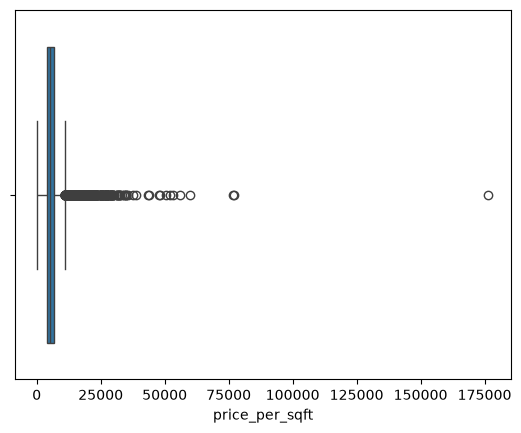

In [20]:
sns.boxplot(x='price_per_sqft',data=df)

In [21]:
q1=df['price_per_sqft'].quantile(0.25)
q3=df['price_per_sqft'].quantile(0.75)
IQR=q3-q1
lower_bound=q1-0.5*IQR
upper_bound=q3+0.5*IQR
df=df[(df['price_per_sqft']>lower_bound) & (df['price_per_sqft']<upper_bound)]
df.info()

<class 'pandas.DataFrame'>
Index: 10350 entries, 0 to 13319
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        10350 non-null  str    
 1   size            10350 non-null  str    
 2   total_sqft      10350 non-null  float64
 3   bath            10350 non-null  float64
 4   price           10350 non-null  float64
 5   bhk             10350 non-null  int64  
 6   price_per_sqft  10350 non-null  float64
dtypes: float64(4), int64(1), str(2)
memory usage: 813.9 KB


In [22]:
df=df[df['bhk']<=6]

In [23]:
df=df[df['bath']<df['bhk']+2]
df.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000


In [24]:
df=df.drop(['size','price_per_sqft'],axis=1)
df.head()

,location,total_sqft,bath,price,bhk
0,Electronic City Phase II,1056.0,2.0,39.07,2
1,Chikka Tirupathi,2600.0,5.0,120.00,4
2,Uttarahalli,1440.0,2.0,62.00,3
3,Lingadheeranahalli,1521.0,3.0,95.00,3
4,Kothanur,1200.0,2.0,51.00,2


In [25]:
df.reset_index(inplace=True)
df=df.drop('index',axis=1)

In [26]:
cleaned=df.copy()

In [27]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['location']=encoder.fit_transform(df[['location']])

c:\Users\DELL\OneDrive\Desktop\BangloreHousePrediction\.venv\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [28]:
X=df.drop('price',axis=1)
y=df['price']

In [29]:
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.3,random_state=42)

In [30]:
model=RandomForestRegressor(random_state=42)
params={
    "n_estimators":[100,150,200,250,300],
    "max_depth":[3,4,5,6]
}
grid=GridSearchCV(estimator=model,param_grid=params,cv=5)
grid.fit(Xtrain,ytrain)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [3, 4, 5, 6],
                         'n_estimators': [100, 150, 200, 250, 300]})

In [31]:
print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Best params: {'max_depth': 6, 'n_estimators': 300}
Best score: 0.8395463166204997


In [32]:
print("Training eff:",grid.score(Xtrain,ytrain))
print("Testing Eff:", grid.score(Xtest,ytest))

Training eff: 0.8917382645794697
Testing Eff: 0.8362095113923503


In [33]:
ypred=grid.predict(Xtest)

In [34]:
print("R2:",r2_score(ytest,ypred))
print('MAE:',mean_absolute_error(ytest,ypred))

R2: 0.8362095113923503
MAE: 14.179111992523515


In [35]:
with open ('RFmodel.pkl', 'wb') as file:
    pickle.dump(grid,file)